# Tratado 2 — Entrenamiento yolo26n (detección de lesión periapical e impactado en panorámicas)

Artículo II: comparación YOLO11n vs. YOLO26n. **Este notebook entrena yolo26n.** Su gemelo entrena el otro modelo; ambos son idénticos salvo el bloque marcado en la celda 0 (`MODEL_NAME`, `MODEL_WEIGHTS`, `FAMILY_DIR`).

Se pueden ejecutar **al mismo tiempo en dos sesiones de Colab distintas**.

Qué garantiza este notebook:
- Mismo dataset, mismo split (verificado por SHA-256 contra la evidencia del Tratado 1).
- Mismo protocolo de entrenamiento (se calcula un hash del diccionario de hiperparámetros para compararlo con el del otro modelo).
- Misma versión de Ultralytics (fijada).
- `test` se evalúa **una sola vez**, con el mejor checkpoint elegido solo con `val`.
- Todo se guarda en Drive: `MODELOS/YOLO26/`. Si Colab se desconecta, se reanuda.

Qué NO mide (a propósito): el tiempo de inferencia comparativo, la matriz de confusión a umbral fijo, los ejemplos TP/FP/FN y los intervalos bootstrap. Eso va en el **Tratado 3 (evaluación conjunta)**, ejecutado en una sola GPU para que la comparación de eficiencia sea justa (las dos sesiones de entrenamiento pueden recibir GPUs distintas).

Pasos:
0. Configuración
1. Dependencias (versión fijada)
2. Dataset: extracción y verificación del split
3. Protocolo de entrenamiento (idéntico para ambos modelos)
4. Entrenamiento (con reanudación)
5. Curvas de entrenamiento
6. Evaluación en val y test (test una sola vez) + métricas por clase
7. Complejidad del modelo (parámetros, tamaño, GFLOPs)
8. Resumen final de la corrida

---

## 0. Configuración

In [1]:
import os, sys, json, shutil, zipfile, hashlib, random, platform, time
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

# ============ ÚNICO BLOQUE QUE CAMBIA ENTRE NOTEBOOKS ============
MODEL_NAME    = "yolo26n"
MODEL_WEIGHTS = "yolo26n.pt"
FAMILY_DIR    = "YOLO26"
# =================================================================

TRAIN_SEED = 42          # semilla de entrenamiento (para repeticiones: 43, 44...). El SPLIT es fijo y no depende de esto.
ULTRALYTICS_VERSION = "8.4.118"   # misma versión en ambos notebooks
IMGSZ = 1024

ROOT        = Path("/content/drive/MyDrive/UNIVERSIDAD/10MO SEMESTRE/ARTICULO II")
DATASET_ZIP = ROOT / "DATASET" / "DENTEX-YOLO-2clases.zip"
META_DIR    = ROOT / "DATASET" / "metadata_dentex"
MODELS_DIR  = ROOT / "MODELOS" / FAMILY_DIR
RUN_NAME    = f"{MODEL_NAME}_seed{TRAIN_SEED}"
RUN_DIR     = MODELS_DIR / RUN_NAME
YOLO_ROOT   = Path("/content/dentex_yolo")   # misma ruta que en el Tratado 1 => data.yaml idéntico (mismo hash)

MODELS_DIR.mkdir(parents=True, exist_ok=True)
random.seed(TRAIN_SEED); np.random.seed(TRAIN_SEED)

import torch
GPU = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print("Modelo:", MODEL_NAME, "| pesos:", MODEL_WEIGHTS)
print("Salida:", RUN_DIR)
print("GPU:", GPU)
assert torch.cuda.is_available(), "Activa GPU: Entorno de ejecución > Cambiar tipo > GPU"

Mounted at /content/drive
Modelo: yolo26n | pesos: yolo26n.pt
Salida: /content/drive/MyDrive/UNIVERSIDAD/10MO SEMESTRE/ARTICULO II/MODELOS/YOLO26/yolo26n_seed42
GPU: Tesla T4


## 1. Dependencias (versión fijada)

In [2]:
%pip install -q "ultralytics==8.4.118"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.7 MB/s eta 0:00:00


> Si pide reiniciar el entorno, reinícialo y vuelve a ejecutar desde la celda 0.

In [3]:
import ultralytics, torch, platform
from ultralytics import YOLO
assert ultralytics.__version__ == ULTRALYTICS_VERSION, ultralytics.__version__
VERSIONS = {"python": platform.python_version(), "ultralytics": ultralytics.__version__,
            "torch": torch.__version__, "cuda": torch.version.cuda, "gpu": GPU}
print(VERSIONS)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
{'python': '3.13.15', 'ultralytics': '8.4.118', 'torch': '2.11.0+cu130', 'cuda': '13.0', 'gpu': 'Tesla T4'}


## 2. Dataset: extracción y verificación del split

In [4]:
if not (YOLO_ROOT / "data.yaml").exists():
    print("Extrayendo", DATASET_ZIP.name, "...")
    with zipfile.ZipFile(DATASET_ZIP) as zf:
        zf.extractall(YOLO_ROOT)

evidence = json.loads((META_DIR / "split_evidence.json").read_text())
sha = lambda b: hashlib.sha256(b).hexdigest()

# (a) data.yaml idéntico al del Tratado 1
yaml_hash = sha((YOLO_ROOT / "data.yaml").read_bytes())
assert yaml_hash == evidence["data_yaml_sha256"], "data.yaml distinto al del Tratado 1"

# (b) listas del split idénticas a las del Tratado 1
split_hashes = {s: sha((YOLO_ROOT / "splits" / f"{s}.txt").read_bytes()) for s in ["train", "val", "test"]}
assert split_hashes == evidence["split_list_sha256"], "Las listas del split no coinciden con la evidencia"

# (c) carpetas en disco == listas, y un label por imagen
for s in ["train", "val", "test"]:
    listed  = set((YOLO_ROOT / "splits" / f"{s}.txt").read_text().split())
    on_disk = {p.name for p in (YOLO_ROOT / "images" / s).iterdir()}
    assert listed == on_disk, f"Imágenes en disco != lista ({s})"
    assert len(list((YOLO_ROOT / "labels" / s).glob("*.txt"))) == len(listed), f"Labels != imágenes ({s})"

# (d) conteos esperados (de las tablas del Tratado 1)
EXPECTED = {"train": dict(images=493, negativas=265, perio=107, imp=428),
            "val":   dict(images=106, negativas=57,  perio=24,  imp=83),
            "test":  dict(images=106, negativas=57,  perio=27,  imp=93)}
OBS = {}
for s in ["train", "val", "test"]:
    n_img = n_neg = n0 = n1 = 0
    for lab in (YOLO_ROOT / "labels" / s).glob("*.txt"):
        rows = [l.split()[0] for l in lab.read_text().splitlines() if l.strip()]
        n_img += 1; n_neg += (len(rows) == 0); n0 += rows.count("0"); n1 += rows.count("1")
    OBS[s] = dict(images=n_img, negativas=n_neg, perio=n0, imp=n1)
assert OBS == EXPECTED, f"Conteos distintos a los esperados:\n{OBS}\n{EXPECTED}"
print(pd.DataFrame(OBS).T)

# (e) huella (fingerprint) del dataset completo: etiquetas + nombres/tamaños de imágenes
h = hashlib.sha256()
for s in ["train", "val", "test"]:
    for lab in sorted((YOLO_ROOT / "labels" / s).glob("*.txt")):
        h.update(f"{s}/{lab.name}\n".encode()); h.update(lab.read_bytes())
    for img in sorted((YOLO_ROOT / "images" / s).iterdir()):
        h.update(f"{s}/{img.name}:{img.stat().st_size}\n".encode())
DATASET_FINGERPRINT = h.hexdigest()

print("\nOK: split verificado contra el Tratado 1")
print("data.yaml sha256 :", yaml_hash)
print("split sha256     :", split_hashes)
print("dataset fingerprint:", DATASET_FINGERPRINT)

Extrayendo DENTEX-YOLO-2clases.zip ...
       images  negativas  perio  imp
train     493        265    107  428
val       106         57     24   83
test      106         57     27   93

OK: split verificado contra el Tratado 1
data.yaml sha256 : 1621825915e761895e379b67ec63ed25f6c75e4e608b5d29a64db75d73a625b1
split sha256     : {'train': '5c2f945aea48c55fa4db3a14d1e6e5053598ba5ded4587c0200c02334dbe3d36', 'val': 'd79395131d954e0879e73ba3dfb06f4b33ae582febe20154591d579c31f9446c', 'test': '9a8f58210b497e25b9198e6070890c2a9292f2e86ea3635645eb54a585f499a1'}
dataset fingerprint: 135b5931ce984659dd046d2fc50774fa87eb6c6cbb018896bfbd3f127026a51b


## 3. Protocolo de entrenamiento (idéntico para ambos modelos)

No se modifica nada entre notebooks. Se fijan **todos** los argumentos de aumento para no depender de los valores por defecto de cada versión del modelo (YOLO11 y YOLO26 pueden diferir en defaults).

In [5]:
TRAIN_ARGS = dict(
    data=str(YOLO_ROOT / "data.yaml"),
    epochs=150, patience=30, imgsz=IMGSZ, batch=16,
    optimizer="AdamW", lr0=0.001, lrf=0.01, momentum=0.937, weight_decay=0.0005, cos_lr=True,
    pretrained=True, seed=TRAIN_SEED, deterministic=True,
    # aumentos (explícitos)
    mosaic=1.0, close_mosaic=15, mixup=0.0,
    fliplr=0.5, flipud=0.0,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=0.0, translate=0.1, scale=0.5, shear=0.0,
    # ejecución
    cache="ram", workers=4, amp=True, plots=True, val=True, exist_ok=True,
)
PROTOCOL_HASH = hashlib.sha256(json.dumps(TRAIN_ARGS, sort_keys=True).encode()).hexdigest()
print(json.dumps(TRAIN_ARGS, indent=2))
print("PROTOCOL_HASH:", PROTOCOL_HASH)

{
  "data": "/content/dentex_yolo/data.yaml",
  "epochs": 150,
  "patience": 30,
  "imgsz": 1024,
  "batch": 16,
  "optimizer": "AdamW",
  "lr0": 0.001,
  "lrf": 0.01,
  "momentum": 0.937,
  "weight_decay": 0.0005,
  "cos_lr": true,
  "pretrained": true,
  "seed": 42,
  "deterministic": true,
  "mosaic": 1.0,
  "close_mosaic": 15,
  "mixup": 0.0,
  "fliplr": 0.5,
  "flipud": 0.0,
  "hsv_h": 0.015,
  "hsv_s": 0.7,
  "hsv_v": 0.4,
  "degrees": 0.0,
  "translate": 0.1,
  "scale": 0.5,
  "shear": 0.0,
  "cache": "ram",
  "workers": 4,
  "amp": true,
  "plots": true,
  "val": true,
  "exist_ok": true
}
PROTOCOL_HASH: 22fbafd193da7772e49e7a7f171a1264d03484fd0c3de4f432ad2902fae08324


> **Comparar este `PROTOCOL_HASH` con el del otro notebook: debe ser idéntico.** Ambos deben dar el mismo valor (con el mismo `TRAIN_SEED`).

## 4. Entrenamiento (con reanudación)

In [6]:
done_flag = RUN_DIR / "TRAINING_DONE.json"
last_pt, best_pt = RUN_DIR / "weights" / "last.pt", RUN_DIR / "weights" / "best.pt"

if done_flag.exists():
    print("Entrenamiento ya completado en una sesión anterior. Se omite.")
else:
    t0 = time.time()
    if last_pt.exists():
        print("Se encontró last.pt: REANUDANDO entrenamiento.")
        YOLO(str(last_pt)).train(resume=True)
    else:
        print("Entrenamiento nuevo.")
        YOLO(MODEL_WEIGHTS).train(project=str(MODELS_DIR), name=RUN_NAME, **TRAIN_ARGS)
    elapsed_min = round((time.time() - t0) / 60, 1)

    res = pd.read_csv(RUN_DIR / "results.csv"); res.columns = [c.strip() for c in res.columns]
    fitness = 0.1 * res["metrics/mAP50(B)"] + 0.9 * res["metrics/mAP50-95(B)"]
    done = {"epochs_completed": int(len(res)), "best_epoch": int(res.loc[fitness.idxmax(), "epoch"]),
            "train_minutes_this_session": elapsed_min, "gpu": GPU,
            "note": "Los minutos solo cuentan esta sesión (si hubo reanudación, no son el total)."}
    done_flag.write_text(json.dumps(done, indent=2))
    print(done)

assert best_pt.exists(), "No existe best.pt"

Entrenamiento nuevo.
New https://pypi.org/project/ultralytics/8.4.174 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.118 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, channels_last=False, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dentex_yolo/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, 

> Si Colab se desconecta: reconecta, ejecuta las celdas 0 a 3 y luego la 4; se reanuda sola desde `last.pt`.

## 5. Curvas de entrenamiento

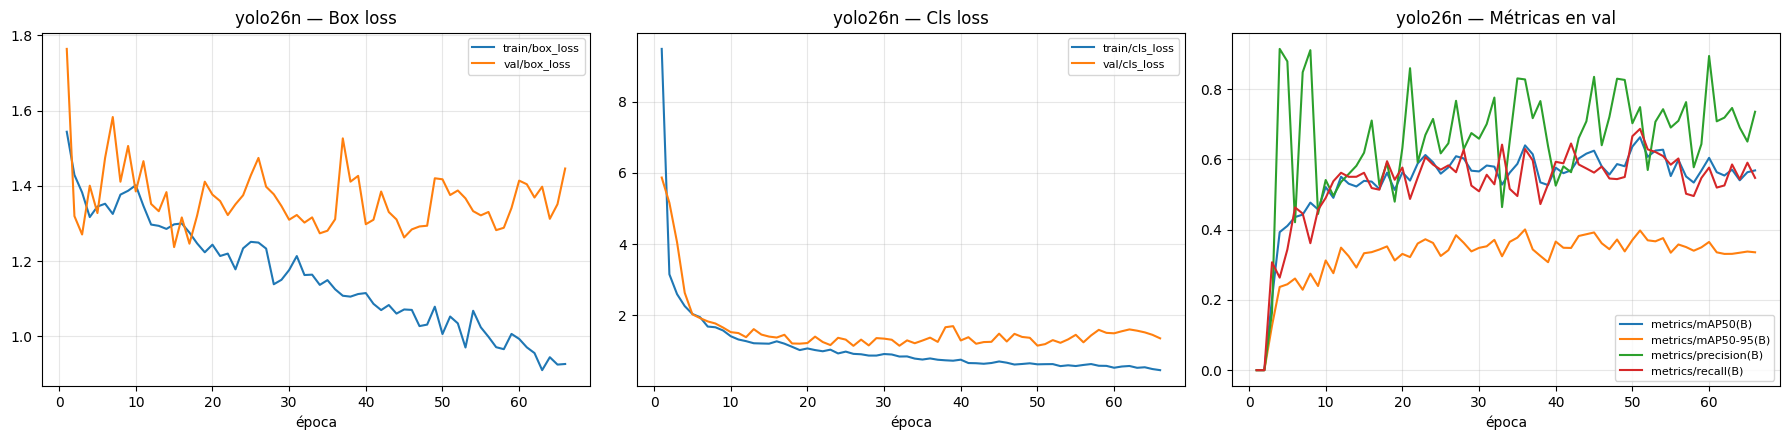

In [7]:
res = pd.read_csv(RUN_DIR / "results.csv"); res.columns = [c.strip() for c in res.columns]
fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
for k in ["train/box_loss", "val/box_loss"]: ax[0].plot(res["epoch"], res[k], label=k)
for k in ["train/cls_loss", "val/cls_loss"]: ax[1].plot(res["epoch"], res[k], label=k)
for k in ["metrics/mAP50(B)", "metrics/mAP50-95(B)", "metrics/precision(B)", "metrics/recall(B)"]:
    ax[2].plot(res["epoch"], res[k], label=k)
for a, t in zip(ax, ["Box loss", "Cls loss", "Métricas en val"]):
    a.set_title(f"{MODEL_NAME} — {t}"); a.set_xlabel("época"); a.legend(fontsize=8); a.grid(alpha=.3)
plt.tight_layout()
fig.savefig(RUN_DIR / f"curvas_entrenamiento_{MODEL_NAME}.png", dpi=130)
plt.show()

## 6. Evaluación en val y test + métricas por clase

- Se usa `best.pt` (elegido con la métrica de validación de Ultralytics: 0.1·mAP@50 + 0.9·mAP@50–95).
- `conf=0.001` y `iou=0.7` (estándar para mAP). Precision/Recall/F1 de Ultralytics se reportan **en el umbral de confianza que maximiza F1**; hay que decirlo en el artículo.
- Se generan automáticamente matriz de confusión, curvas PR y F1 en `eval_val/` y `eval_test/`.
- **`test` se evalúa una sola vez**: queda una marca y la celda no vuelve a ejecutarlo.

In [8]:
CLASS_NAMES = ["periapical_lesion", "impacted_tooth"]

def eval_split(split):
    r = YOLO(str(best_pt)).val(data=str(YOLO_ROOT / "data.yaml"), split=split, imgsz=IMGSZ, batch=16,
                               conf=0.001, iou=0.7, plots=True, project=str(RUN_DIR),
                               name=f"eval_{split}", exist_ok=True, verbose=False)
    b = r.box
    P, R = float(b.mp), float(b.mr)
    overall = {"split": split, "precision": P, "recall": R,
               "f1": 2 * P * R / (P + R + 1e-12),
               "mAP50": float(b.map50), "mAP50_95": float(b.map)}
    idx = list(b.ap_class_index)
    rows = []
    for j, ci in enumerate(idx):
        p, rc = float(b.p[j]), float(b.r[j])
        rows.append({"clase": CLASS_NAMES[int(ci)],
                     "instancias": EXPECTED[split]["perio" if int(ci) == 0 else "imp"],
                     "precision": p, "recall": rc, "f1": 2 * p * rc / (p + rc + 1e-12),
                     "AP50": float(b.ap50[j]), "AP50_95": float(b.ap[j])})
    return overall, pd.DataFrame(rows), dict(r.speed)

# ---- val (se puede repetir) ----
ov_val, pc_val, _ = eval_split("val")
pc_val.to_csv(RUN_DIR / "metricas_por_clase_val.csv", index=False)
print("VAL:", {k: round(v, 4) if isinstance(v, float) else v for k, v in ov_val.items()})
display(pc_val.round(4))

# ---- test (UNA sola vez) ----
test_flag = RUN_DIR / "TEST_EVAL_DONE.json"
if test_flag.exists():
    print("\nTEST ya evaluado. Se carga el resultado guardado (no se vuelve a evaluar).")
    saved = json.loads(test_flag.read_text()); ov_test = saved["overall"]
    pc_test = pd.read_csv(RUN_DIR / "metricas_por_clase_test.csv")
else:
    ov_test, pc_test, speed_ul = eval_split("test")
    pc_test.to_csv(RUN_DIR / "metricas_por_clase_test.csv", index=False)
    test_flag.write_text(json.dumps({"overall": ov_test, "ultralytics_speed_ms": speed_ul,
                                     "gpu": GPU, "timestamp": datetime.now().isoformat()}, indent=2))
print("\nTEST:", {k: round(v, 4) if isinstance(v, float) else v for k, v in ov_test.items()})
display(pc_test.round(4))

Ultralytics 8.4.118 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2967.7±533.9 MB/s, size: 3756.3 KB)
val: Scanning /content/dentex_yolo/labels/val.cache... 106 images, 57 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 106/106 26.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.5s/it 10.7s
                   all        106        107      0.806      0.637      0.641      0.399
Speed: 6.3ms preprocess, 11.4ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/drive/MyDrive/UNIVERSIDAD/10MO SEMESTRE/ARTICULO II/MODELOS/YOLO26/yolo26n_seed42/eval_val
VAL: {'split': 'val', 'precision': 0.8062, 'recall': 0.6365, 'f1': 0.7114, 'mAP50': 0.6405, 'mAP50_95': 0.3994}


,clase,instancias,precision,recall,f1,AP50,AP50_95
0,periapical_lesion,24,0.8507,0.3333,0.4790,0.3646,0.2246
1,impacted_tooth,83,0.7618,0.9398,0.8415,0.9165,0.5743


Ultralytics 8.4.118 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 192.1±91.5 MB/s, size: 4508.7 KB)
val: Scanning /content/dentex_yolo/labels/test... 106 images, 57 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 106/106 61.7it/s 1.7s
val: New cache created: /content/dentex_yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.5s/it 10.8s
                   all        106        120      0.613      0.546      0.552      0.353
Speed: 6.7ms preprocess, 12.9ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /content/drive/MyDrive/UNIVERSIDAD/10MO SEMESTRE/ARTICULO II/MODELOS/YOLO26/yolo26n_seed42/eval_test

TEST: {'split': 'test', 'precision': 0.6127, 'recall': 0.5456, 'f1': 0.5772, 'mAP50': 0.5516, 'mAP50_95': 0.3531}


,clase,instancias,precision,recall,f1,AP50,AP50_95
0,periapical_lesion,27,0.5365,0.2573,0.3478,0.2539,0.1633
1,impacted_tooth,93,0.6890,0.8338,0.7545,0.8492,0.5430


Archivos útiles para el artículo (en `RUN_DIR/eval_test/`): `confusion_matrix.png`, `confusion_matrix_normalized.png`, `BoxPR_curve.png`, `BoxF1_curve.png`.

## 7. Complejidad del modelo

In [9]:
m = YOLO(str(best_pt))
try:
    n_layers, n_params, _, gflops = m.info(verbose=False, imgsz=IMGSZ)
except Exception as e:
    print("m.info falló, se calcula manualmente:", e)
    from ultralytics.utils.torch_utils import get_flops
    n_params = sum(p.numel() for p in m.model.parameters())
    gflops = get_flops(m.model, imgsz=IMGSZ)

complexity = {"parametros": int(n_params), "gflops_a_imgsz": float(gflops), "imgsz_gflops": IMGSZ,
              "tamano_best_pt_MB": round(best_pt.stat().st_size / 1e6, 2)}
print(complexity)

m.info falló, se calcula manualmente: cannot unpack non-iterable NoneType object
{'parametros': 2504580, 'gflops_a_imgsz': 15.580266496, 'imgsz_gflops': 1024, 'tamano_best_pt_MB': 5.42}


> Los GFLOPs dependen de `imgsz` (aquí 1024). Compara siempre ambos modelos al mismo `imgsz`.

## 8. Resumen final de la corrida

In [10]:
summary = {
    "model": MODEL_NAME, "weights_init": MODEL_WEIGHTS, "train_seed": TRAIN_SEED,
    "versions": VERSIONS, "protocol_hash": PROTOCOL_HASH, "train_args": TRAIN_ARGS,
    "dataset": {"data_yaml_sha256": yaml_hash, "split_list_sha256": split_hashes,
                "fingerprint": DATASET_FINGERPRINT, "counts": OBS},
    "training": json.loads(done_flag.read_text()),
    "val": ov_val, "test": ov_test, "complexity": complexity,
    "paths": {"run_dir": str(RUN_DIR), "best": str(best_pt)},
    "created": datetime.now().isoformat(),
}
(RUN_DIR / "run_summary.json").write_text(json.dumps(summary, indent=2, default=str))
print(json.dumps({k: summary[k] for k in ["model", "protocol_hash", "val", "test", "complexity"]}, indent=2, default=str))
print("\nGuardado en:", RUN_DIR)

{
  "model": "yolo26n",
  "protocol_hash": "22fbafd193da7772e49e7a7f171a1264d03484fd0c3de4f432ad2902fae08324",
  "val": {
    "split": "val",
    "precision": 0.8062266537542968,
    "recall": 0.6365461847389559,
    "f1": 0.7114085970980069,
    "mAP50": 0.6405376571180528,
    "mAP50_95": 0.3994358138514514
  },
  "test": {
    "split": "test",
    "precision": 0.6127387394838701,
    "recall": 0.5455776160456677,
    "f1": 0.5772111205203885,
    "mAP50": 0.5515927011503972,
    "mAP50_95": 0.35314129633889524
  },
  "complexity": {
    "parametros": 2504580,
    "gflops_a_imgsz": 15.580266496,
    "imgsz_gflops": 1024,
    "tamano_best_pt_MB": 5.42
  }
}

Guardado en: /content/drive/MyDrive/UNIVERSIDAD/10MO SEMESTRE/ARTICULO II/MODELOS/YOLO26/yolo26n_seed42


### Checklist al terminar

- [ ] `PROTOCOL_HASH` idéntico al del otro notebook.
- [ ] `dataset fingerprint` idéntico al del otro notebook.
- [ ] `best.pt`, `results.csv`, `run_summary.json` y `eval_test/` presentes en `MODELOS/YOLO26/yolo26n_seed42/`.
- [ ] No tocar `test` otra vez (la marca `TEST_EVAL_DONE.json` lo impide).

### Notas para el repositorio

- Subir a GitHub: este notebook, `run_summary.json`, `results.csv`, `args.yaml`, `metricas_por_clase_*.csv` y las figuras. Los pesos `best.pt` (~5 MB) pueden subirse al repositorio o a Releases/Zenodo si la licencia lo permite.
- Para repeticiones con más semillas: cambiar solo `TRAIN_SEED` (43, 44). El split no cambia.